In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import make_column_transformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

In [28]:
data_path = r".\dataset\insurance.csv"
df = pd.read_csv(data_path)


In [29]:
df_feat = df.copy()
df_feat.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [30]:
df_feat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [31]:
def preprocessing_pipeline(dataframe, target):
    X = dataframe.drop(target, axis=1)
    y = dataframe[target]

    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    categorical_selector = make_column_selector(dtype_include=["object", "category"])
    numerical_selector = make_column_selector(dtype_include=np.number)

    preprocessing = make_column_transformer(
        (OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_selector),
        (StandardScaler(), numerical_selector),
        remainder="drop"
    )
    return x_train, x_test, y_train, y_test, preprocessing

In [32]:
def linear_regression_model(x_train,preprocessing_pipeline, y_train):
    model_pipeline = make_pipeline(preprocessing_pipeline, LinearRegression())
    model_pipeline.fit(x_train, y_train)
    return model_pipeline

In [55]:
def linear_regression_diagnostics(model_pipeline, x_train,xtest, y_train,ytest):

    preprocessor = model_pipeline[:-1]
    x_train_processed = preprocessor.transform(x_train)
    xtest_processed = preprocessor.transform(xtest)

    
    try:
        feature_names = preprocessor.get_feature_names_out()
    except:
        feature_names = [f"x{i}" for i in range(x_train_processed.shape[1])]

    x_train_processed = pd.DataFrame(x_train_processed, columns=feature_names)
    
    # Predictions
    y_pred_train = model_pipeline.predict(x_train)
    y_pred_test = model_pipeline.predict(xtest)

    
    # Performance Metrics
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(ytest, y_pred_test)
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(ytest, y_pred_test)
    
    print(f"R² Score (Train): {r2_train:.4f}")
    print(f"R² Score (Test): {r2_test:.4f}")
    print(f"MSE (Train): {mse_train:.4f}")
    print(f"MSE (Test): {mse_test:.4f}")
    
    # Residuals
    residuals = y_train - y_pred_train
    
    print("=" * 55)
    print("LINEAR REGRESSION — FULL ASSUMPTION DIAGNOSTICS")
    print("=" * 55)

    # ─────────────────────────────────────────────────────────────────
    # ASSUMPTION 1 — LINEARITY
    # Visual only: scatter each feature vs y
    # ─────────────────────────────────────────────────────────────────
    print("\n[1] LINEARITY → Check scatter plots (x vs y)")
    print("    No single number — use your eyes on the plots below.")

    # ─────────────────────────────────────────────────────────────────
    # ASSUMPTION 2 — INDEPENDENCE (Durbin-Watson)
    # ─────────────────────────────────────────────────────────────────
    dw = durbin_watson(residuals)
    print(f"\n[2] INDEPENDENCE — Durbin-Watson")
    print(f"    DW statistic : {dw:.4f}")
    if 1.5 <= dw <= 2.5:
        print("    Result       : PASSED ✓ (between 1.5 and 2.5)")
    elif dw < 1.5:
        print("    Result       : FAILED ✗ — positive autocorrelation")
    else:
        print("    Result       : FAILED ✗ — negative autocorrelation")

    # ─────────────────────────────────────────────────────────────────
    # ASSUMPTION 3 — NORMALITY (Shapiro-Wilk)
    # ─────────────────────────────────────────────────────────────────
    stat_sw, p_sw = stats.shapiro(residuals)
    print(f"\n[3] NORMALITY — Shapiro-Wilk")
    print(f"    Statistic : {stat_sw:.4f}")
    print(f"    p-value   : {p_sw:.4f}")
    if p_sw > 0.05:
        print("    Result    : PASSED ✓ (p > 0.05)")
    else:
        print("    Result    : FAILED ✗ (p < 0.05)")

    # ─────────────────────────────────────────────────────────────────
    # ASSUMPTION 4 — EQUAL VARIANCE (Breusch-Pagan)
    # ─────────────────────────────────────────────────────────────────
    X_with_const  = sm.add_constant(x_train_processed)
    bp_stat, p_bp, _, _ = het_breuschpagan(residuals, X_with_const)
    print(f"\n[4] EQUAL VARIANCE — Breusch-Pagan")
    print(f"    Statistic : {bp_stat:.4f}")
    print(f"    p-value   : {p_bp:.4f}")
    if p_bp > 0.05:
        print("    Result    : PASSED ✓ (p > 0.05 — homoscedastic)")
    else:
        print("    Result    : FAILED ✗ (p < 0.05 — heteroscedastic)")

    # ─────────────────────────────────────────────────────────────────
    # ASSUMPTION 5 — MULTICOLLINEARITY (VIF)
    # ─────────────────────────────────────────────────────────────────
    print(f"\n[5] MULTICOLLINEARITY — VIF scores")
    vif_data = pd.DataFrame()
    vif_data['Feature'] = x_train_processed.columns
    vif_data['VIF']     = [variance_inflation_factor(x_train_processed.values, i)
                            for i in range(x_train_processed.shape[1])]
    print(vif_data.to_string(index=False))
    for _, row in vif_data.iterrows():
        if row['VIF'] > 10:
            print(f"    WARNING ✗ : {row['Feature']} has VIF={row['VIF']:.1f} — serious problem")
        elif row['VIF'] > 5:
            print(f"    CAUTION   : {row['Feature']} has VIF={row['VIF']:.1f} — moderate concern")
        else:
            print(f"    OK ✓      : {row['Feature']} has VIF={row['VIF']:.1f}")

    # ─────────────────────────────────────────────────────────────────
    # PLOTS — All visuals in one figure
    # ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Assumption Diagnostics', fontsize=14)

    # 1. Linearity: x1 vs y (do this for every feature)
    first_feature = x_train.columns[0]
    axes[0,0].scatter(x_train[first_feature], y_train, alpha=0.2,s=15,edgecolor='None')
    axes[0,0].set_title(f'Linearity — {first_feature} vs y')
    axes[0,0].set_xlabel('x1'); axes[0,0].set_ylabel('y')

    # 2. Independence: residuals vs row order
    axes[0,1].plot(residuals.values, color='purple', alpha=0.6, linewidth=0.8)
    axes[0,1].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[0,1].set_title(f'Independence — residuals over time (DW={dw:.2f})')
    axes[0,1].set_xlabel('Row order'); axes[0,1].set_ylabel('Residual')

    # 3. Normality: Q-Q plot
    stats.probplot(residuals, dist="norm", plot=axes[0,2])
    axes[0,2].set_title(f'Normality — Q-Q plot (p={p_sw:.3f})')

    # 4. Equal variance: residuals vs fitted
    sns.kdeplot(
        x=y_pred_train,
        y=residuals,
        fill=True,
        ax=axes[1,0]
    )
    axes[1,0].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[1,0].set_title(f'Equal Variance — residuals vs fitted (p={p_bp:.3f})')
    axes[1,0].set_xlabel('Fitted values'); axes[1,0].set_ylabel('Residuals')

    # 5. Multicollinearity: correlation heatmap
    corr = x_train_processed.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm',
                center=0, ax=axes[1,1], square=True,fmt='.2f',cbar_kws={"shrink": 0.7}, vmin=-1, vmax=1)
    axes[1,1].set_title('Multicollinearity — correlation heatmap')

    # 6. VIF bar chart
    colors = ['green' if v < 5 else 'orange' if v < 10 else 'red'
            for v in vif_data['VIF']]
    axes[1,2].bar(vif_data['Feature'], vif_data['VIF'], color=colors)
    axes[1,2].tick_params(axis='x', rotation=90)
    axes[1,2].axhline(5,  color='orange', linestyle='--', linewidth=1.2, label='VIF=5')
    axes[1,2].axhline(10, color='red',    linestyle='--', linewidth=1.2, label='VIF=10')
    axes[1,2].set_title('Multicollinearity — VIF scores')
    axes[1,2].set_ylabel('VIF'); axes[1,2].legend()

    plt.tight_layout()
    plt.show()

R² Score (Train): 0.7417
R² Score (Test): 0.7836
MSE (Train): 37277681.7020
MSE (Test): 33596915.8514
LINEAR REGRESSION — FULL ASSUMPTION DIAGNOSTICS

[1] LINEARITY → Check scatter plots (x vs y)
    No single number — use your eyes on the plots below.

[2] INDEPENDENCE — Durbin-Watson
    DW statistic : 2.0854
    Result       : PASSED ✓ (between 1.5 and 2.5)

[3] NORMALITY — Shapiro-Wilk
    Statistic : 0.8944
    p-value   : 0.0000
    Result    : FAILED ✗ (p < 0.05)

[4] EQUAL VARIANCE — Breusch-Pagan
    Statistic : 93.3446
    p-value   : 0.0000
    Result    : FAILED ✗ (p < 0.05 — heteroscedastic)

[5] MULTICOLLINEARITY — VIF scores
                        Feature      VIF
        onehotencoder__sex_male 1.674422
      onehotencoder__smoker_yes 1.224764
onehotencoder__region_northwest 1.235911
onehotencoder__region_southeast 1.323629
onehotencoder__region_southwest 1.216686
            standardscaler__age 1.022850
            standardscaler__bmi 1.078133
       standardscaler__c

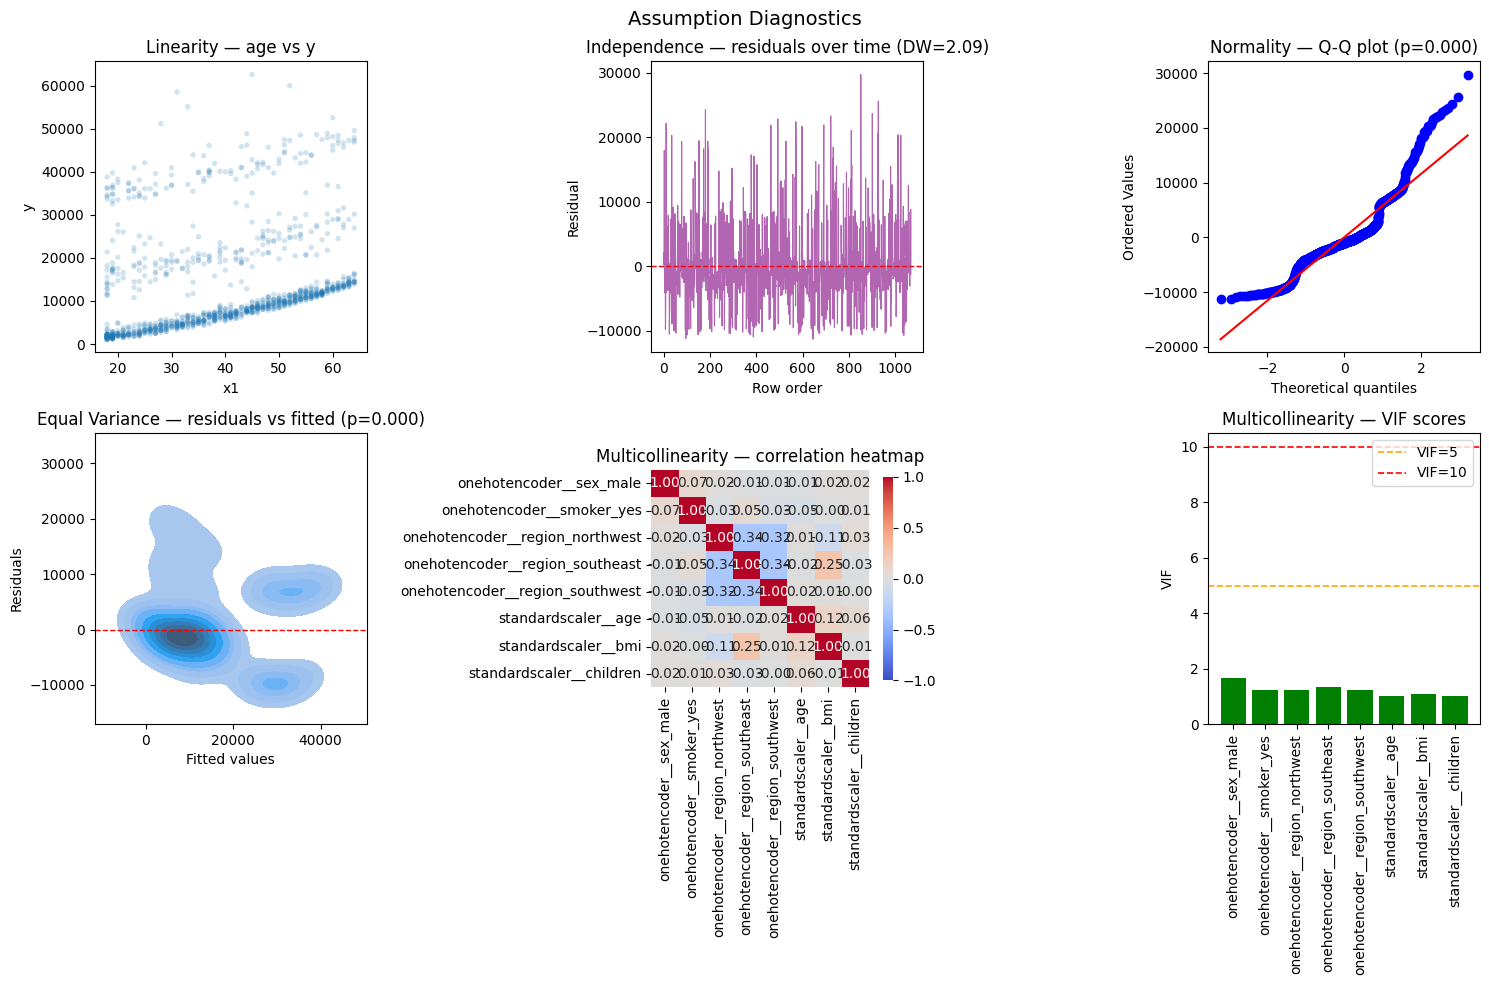

In [56]:
x_train, x_test, y_train, y_test, preprocessing_pipeline_ret = preprocessing_pipeline(df_feat, target='charges')
model_pipeline = linear_regression_model(x_train, preprocessing_pipeline_ret, y_train)
linear_regression_diagnostics(model_pipeline, x_train, x_test, y_train, y_test)

In [ ]:
# X = df_engineered.drop(columns=['log_charges', 'age', 'bmi', 'charges'])
# Y = df_engineered['log_charges']
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# stratify_cols = X['age_group'].astype(str) + '_' + \
#                 X['bmi_category'].astype(str) + '_' + \
#                 X['smoker'].astype(str)


# X_train, X_test, y_train, y_test = train_test_split(
#     X, Y,
#     test_size=0.2,
#     random_state=42,
#     shuffle=True,
#     stratify=X['smoker']  # ← single argument!
# )

# category_selector = make_column_selector(pattern="cat")
# object_selector = make_column_selector(dtype_include=object)
# numerical_selector = ['children','bmi_risk','age_risk']

# preprocessing_pipeline = make_column_transformer(
#     (OneHotEncoder(handle_unknown="ignore"), category_selector),
#     (OneHotEncoder(handle_unknown="ignore"), object_selector),
#     (StandardScaler(), numerical_selector),
#     remainder="drop")

# model_pipeline = make_pipeline(
#     preprocessing_pipeline,
#     LinearRegression()
# )

# kfold = KFold(n_splits=5, shuffle=True, random_state=42)
# results  = cross_validate(model_pipeline, X_train, y_train, cv=kfold,scoring='neg_mean_squared_error', return_estimator=True )
# print(results.keys())
# rmse_scores = np.sqrt(-results['test_score'])
# print(f"RMSE scores: {rmse_scores}")
# print(f"Mean RMSE: {rmse_scores.mean():.3f} (+/- {rmse_scores.std():.3f})")
# # Access feature names from first fold's estimator
# first_model = results['estimator'][0]
# sed_model = results['estimator'][1]
# feature_names = first_model.named_steps['columntransformer'].get_feature_names_out()
# print(f"Features: {feature_names}")


In [ ]:
# X = df_feat.drop("charges", axis=1)
# y = df_feat["charges"]

# category_selector = make_column_selector(pattern="cat")
# object_selector = make_column_selector(dtype_include=object)
# numerical_selector = ['age', 'bmi', 'children']

# preprocessing_pipeline = make_column_transformer(
#     (OneHotEncoder(handle_unknown="ignore"), category_selector),
#     (OneHotEncoder(handle_unknown="ignore"), object_selector),
#     (StandardScaler(), numerical_selector),
#     remainder="drop")

# model_pipeline = make_pipeline(
#     preprocessing_pipeline,
#     LinearRegression()
# )

In [ ]:
def linear_regression_diagnostics(dataframe, target, K=5):
    X = dataframe.drop(target, axis=1)
    y = dataframe[target]

    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    categorical_selector = make_column_selector(dtype_include=["object", "category"])
    numerical_selector = make_column_selector(dtype_include=np.number)

    # target_preprocessing_pipeline = make_column_transformer(
    #     (np.log1p, make_column_selector(target)),
    #     remainder="passthrough")

    preprocessing_pipeline = make_column_transformer(
        (OneHotEncoder(handle_unknown="ignore"), categorical_selector),
        (StandardScaler(), numerical_selector),
        remainder="drop")

    model_pipeline = make_pipeline(
        preprocessing_pipeline,
        # target_preprocessing_pipeline,
        LinearRegression()
    )

    model_pipeline.fit(x_train, y_train)

    y_pred = model_pipeline.predict(x_test)

    print("\nModel Performance")
    print("R2 Score:", r2_score(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

    kf = KFold(n_splits=K, shuffle=True, random_state=42)
    cv_scores = cross_val_score(
        model_pipeline,
        X,
        y,
        cv=kf,
        scoring="r2"
    )

    print("\nCross Validation Scores:", cv_scores)
    print("Mean CV Score:", cv_scores.mean())
        # Residuals Analysis
    residuals = y_test - y_pred

    fig, axes = plt.subplots(3,2, figsize=(15,12))

    # Residual plot
    axes[0,0].scatter(y_pred, residuals)
    axes[0,0].axhline(0, color='red', linestyle='--')
    axes[0,0].set_title("Residuals vs Predicted")

    # Numeric features
    axes[0,1].scatter(dataframe['age'], y)
    axes[0,1].set_title("Age vs Charges")

    axes[1,0].scatter(dataframe['bmi'], y)
    axes[1,0].set_title("BMI vs Charges")

    axes[1,1].scatter(dataframe['children'], y)
    axes[1,1].set_title("Children vs Charges")

    # Categorical features
    sns.boxplot(x=dataframe['smoker'], y=y, ax=axes[2,0])
    axes[2,0].set_title("Smoker vs Charges")

    sns.boxplot(x=dataframe['region'], y=y, ax=axes[2,1])
    axes[2,1].set_title("Region vs Charges")

    plt.tight_layout()
    plt.show()



    # Linearity Check
    plt.figure(figsize=(12,5))
    sns.scatterplot(x=y_pred, y=residuals)
    plt.axhline(0, color='red', linestyle='--')
    plt.title('Residuals vs Predicted Values (Checking Linearity)')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.show()

    # Normality Check
    plt.figure(figsize=(12,5))
    sns.histplot(residuals, kde=True)
    plt.title('Distribution of Residuals')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.show()

    sm.qqplot(residuals, line='s')
    plt.title('Q-Q Plot of Residuals')
    plt.show()

    # Homoscedasticity Check
    plt.figure(figsize=(12,5))
    sns.scatterplot(x=y_pred, y=residuals)
    plt.title('Homoscedasticity Check')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.show()

    # Multicollinearity (VIF)
    print("\nVariance Inflation Factor (VIF)")
    X_transformed = model_pipeline.named_steps['columntransformer'].transform(X)

 

    # Independence of Errors
    dw = sm.stats.stattools.durbin_watson(residuals)
    print("\nDurbin-Watson Statistic (Independence of Errors):", dw)
    feature_names = model_pipeline.named_steps['columntransformer'].get_feature_names_out()
    # Model Interpretation
    coefficients = pd.DataFrame({
        "feature": feature_names,
        "coefficient": model_pipeline.named_steps["linearregression"].coef_
    })
    print(coefficients.sort_values("coefficient", ascending=False))

    return model_pipeline



Model Performance
R2 Score: 0.7835929767120723
RMSE: 5796.2846592762735

Cross Validation Scores: [0.78359298 0.7380458  0.79558615 0.63243806 0.75131533]
Mean CV Score: 0.7401956629640443


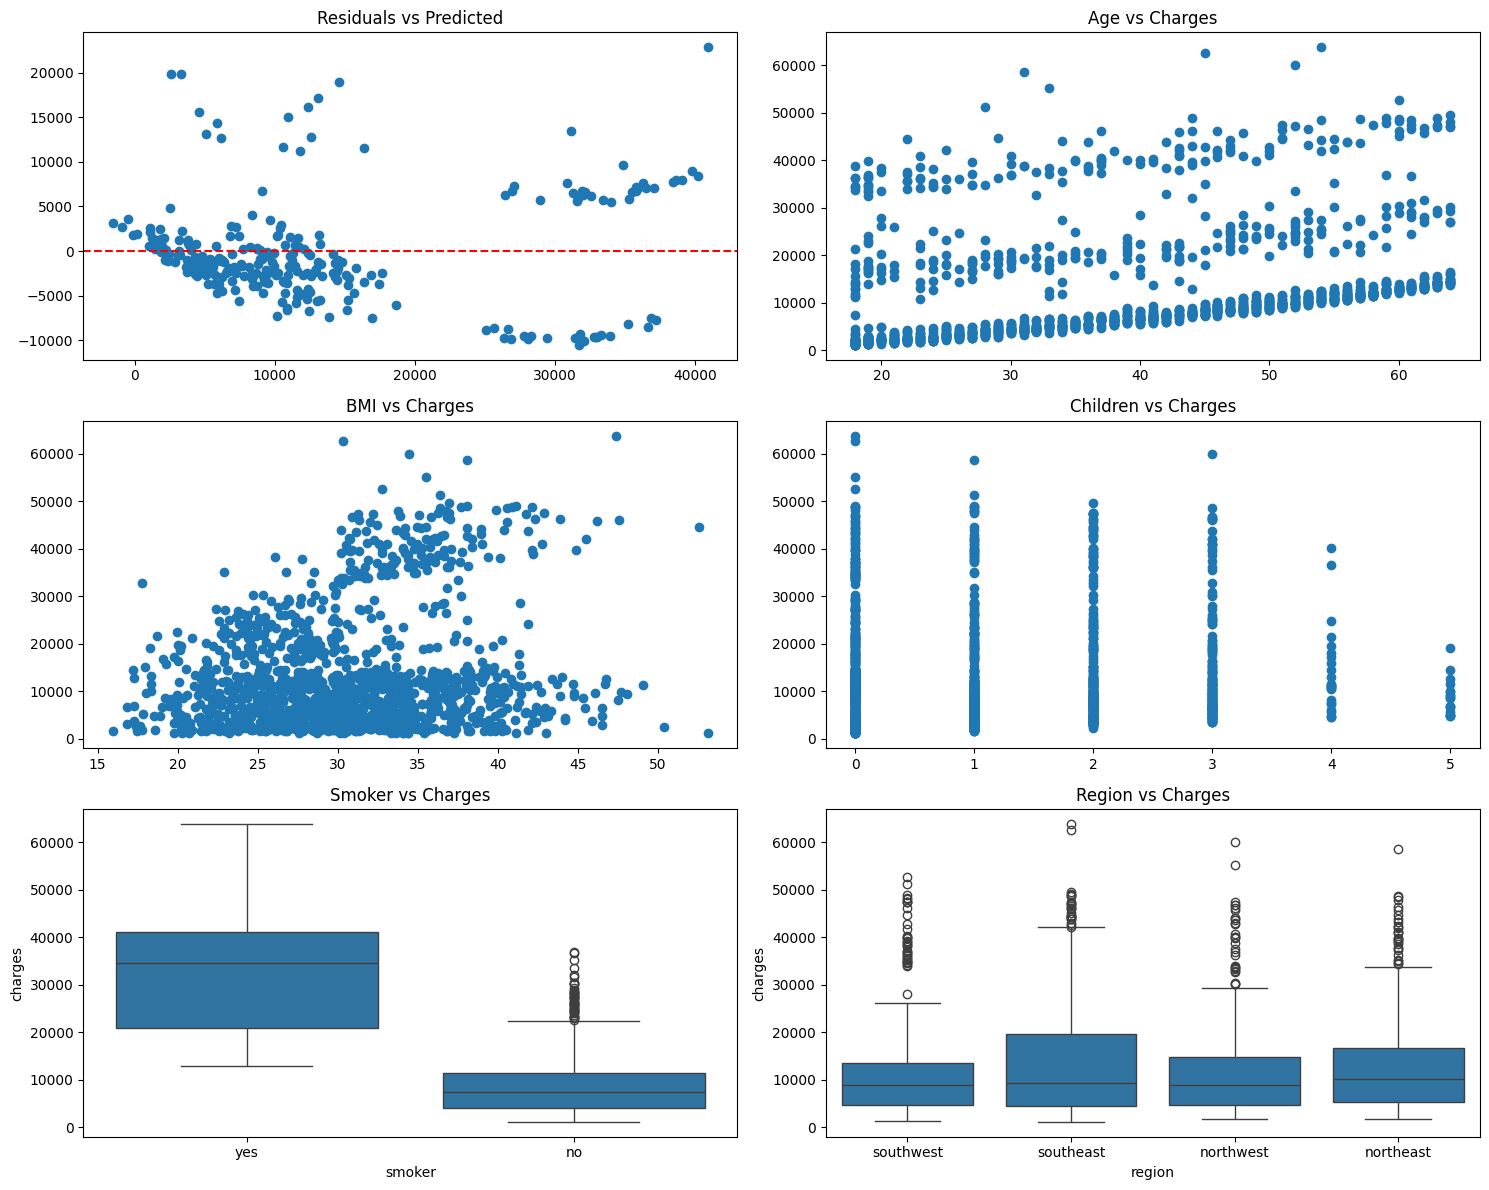

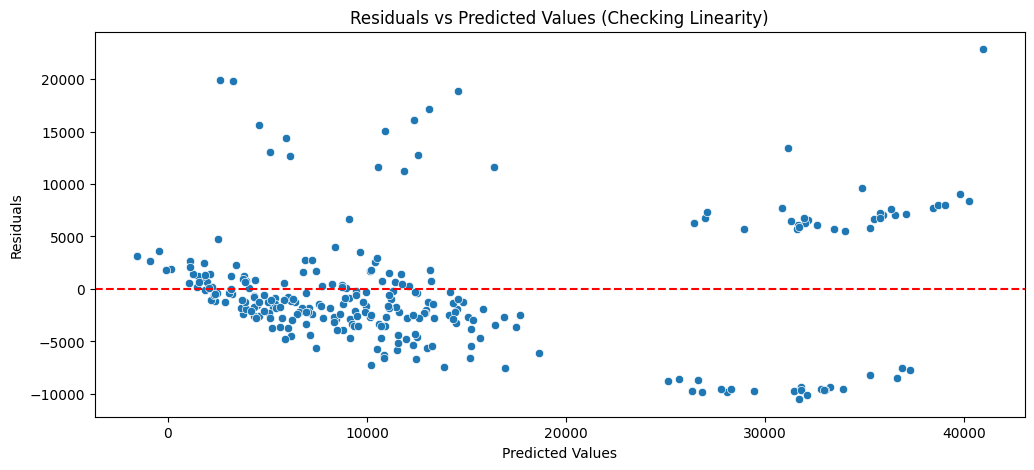

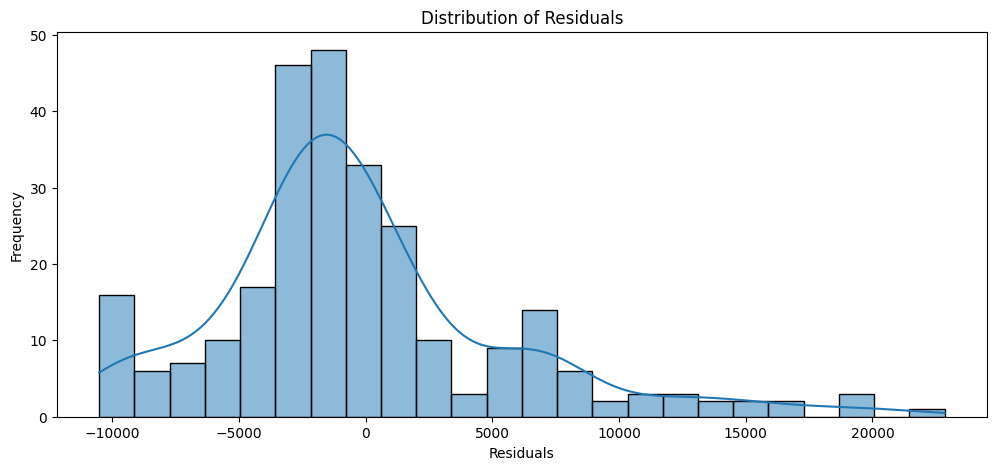

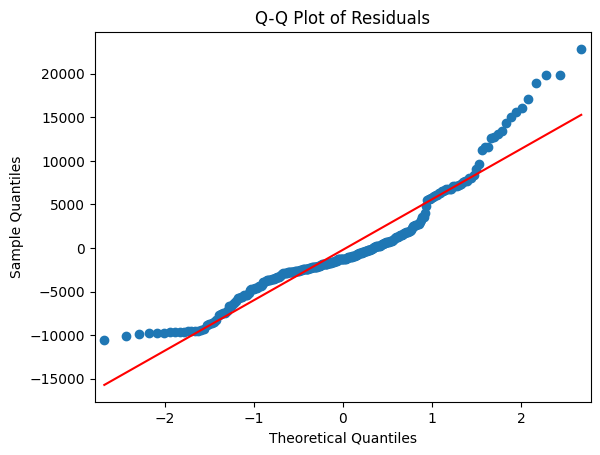

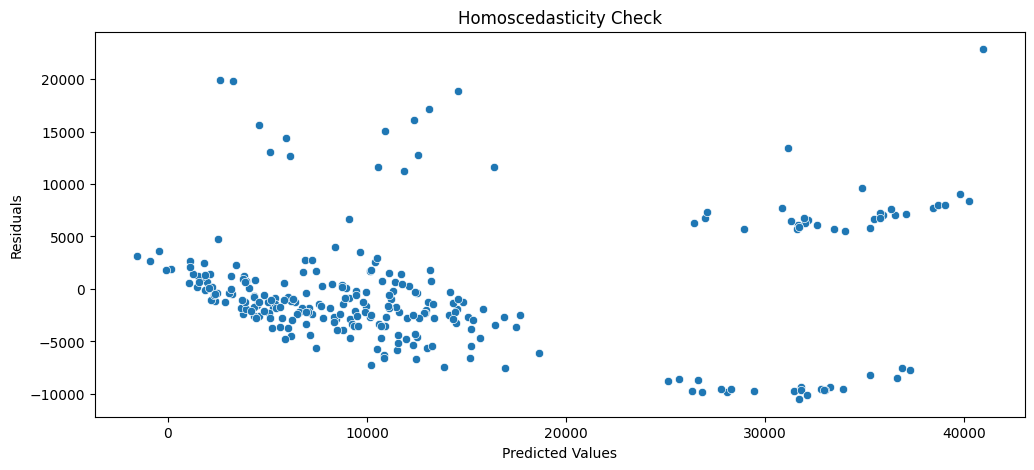


Variance Inflation Factor (VIF)

Durbin-Watson Statistic (Independence of Errors): 2.190540770682535
                            feature   coefficient
3         onehotencoder__smoker_yes  11825.564428
8               standardscaler__age   3614.975415
9               standardscaler__bmi   2036.228123
10         standardscaler__children    516.890247
4   onehotencoder__region_northeast    459.585244
5   onehotencoder__region_northwest     88.907918
0         onehotencoder__sex_female      9.295846
1           onehotencoder__sex_male     -9.295846
6   onehotencoder__region_southeast   -198.279052
7   onehotencoder__region_southwest   -350.214110
2          onehotencoder__smoker_no -11825.564428


In [ ]:
model = linear_regression_diagnostics(df_feat, target="charges")

In [ ]:
def linear_regression_diagnostics_updated(dataframe, target, K=5):

    X = dataframe.drop(columns=[target])
    y = dataframe[target]

    x_train, x_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    categorical_selector = make_column_selector(dtype_include=["object", "category"])
    numerical_selector = make_column_selector(dtype_include=np.number)

    preprocessing = make_column_transformer(
        (OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_selector),
        (StandardScaler(), numerical_selector),
        remainder="drop"
    )

    model = TransformedTargetRegressor(
        regressor=LinearRegression(),
        func=np.log1p,
        inverse_func=np.expm1
    )

    pipeline = make_pipeline(
        preprocessing,
        model
    )

    pipeline.fit(x_train, y_train)

    y_pred = pipeline.predict(x_test)

    print("\nMODEL PERFORMANCE")
    print("R2:", r2_score(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

    # Cross Validation
    kf = KFold(n_splits=K, shuffle=True, random_state=42)

    cv_scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=kf,
        scoring="r2"
    )

    print("\nCROSS VALIDATION")
    print("Scores:", cv_scores)
    print("Mean:", cv_scores.mean())

    residuals = y_test - y_pred

    # -------------------------
    # Residual Diagnostics
    # -------------------------

    plt.figure(figsize=(8,5))
    sns.scatterplot(x=y_pred, y=residuals)
    plt.axhline(0, linestyle="--", color="red")
    plt.title("Residuals vs Predictions")
    plt.show()

    plt.figure(figsize=(8,5))
    sns.histplot(residuals, kde=True)
    plt.title("Residual Distribution")
    plt.show()

    sm.qqplot(residuals, line="s")
    plt.title("QQ Plot")
    plt.show()

    # -------------------------
    # Statistical Tests
    # -------------------------

    print("\nNORMALITY TEST (Shapiro)")
    shapiro_stat, shapiro_p = shapiro(residuals)
    print("Statistic:", shapiro_stat)
    print("p-value:", shapiro_p)

    print("\nDURBIN WATSON (Independence)")
    dw = sm.stats.stattools.durbin_watson(residuals)
    print("Durbin-Watson:", dw)

    # -------------------------
    # VIF
    # -------------------------

    print("\nMULTICOLLINEARITY (VIF)")

    X_transformed = pipeline.named_steps["columntransformer"].transform(X)
    feature_names = pipeline.named_steps["columntransformer"].get_feature_names_out()

    vif_data = pd.DataFrame()
    vif_data["feature"] = feature_names
    vif_data["VIF"] = [
        variance_inflation_factor(X_transformed, i)
        for i in range(X_transformed.shape[1])
    ]

    print(vif_data.sort_values("VIF", ascending=False))

    # -------------------------
    # Breusch Pagan
    # -------------------------

    print("\nHETEROSCEDASTICITY (Breusch-Pagan)")

    lm, lm_pvalue, fvalue, f_pvalue = het_breuschpagan(
        residuals,
        sm.add_constant(y_pred)
    )

    print("LM Statistic:", lm)
    print("p-value:", lm_pvalue)

    # -------------------------
    # Coefficients
    # -------------------------

    print("\nMODEL COEFFICIENTS")

    coefs = pipeline.named_steps["transformedtargetregressor"].regressor_.coef_

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs
    })

    print(coef_df.sort_values("coefficient", ascending=False))

    return pipeline


MODEL PERFORMANCE
R2: 0.6066982575915607
RMSE: 7814.064025999177

CROSS VALIDATION
Scores: [0.60669826 0.61177515 0.51983572 0.34224387 0.45701817]
Mean: 0.5075142343141088


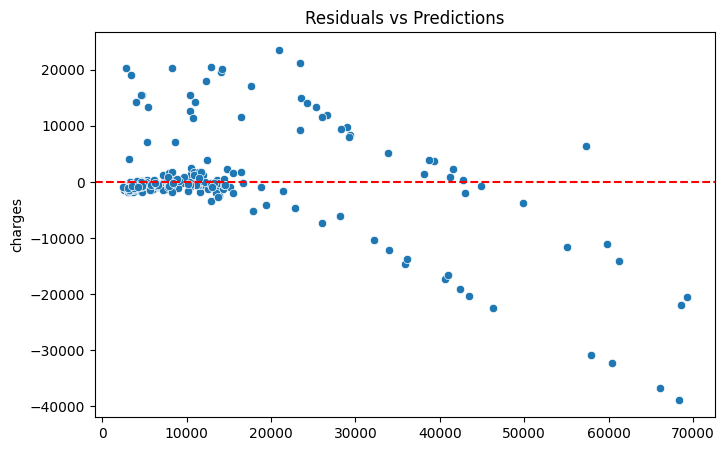

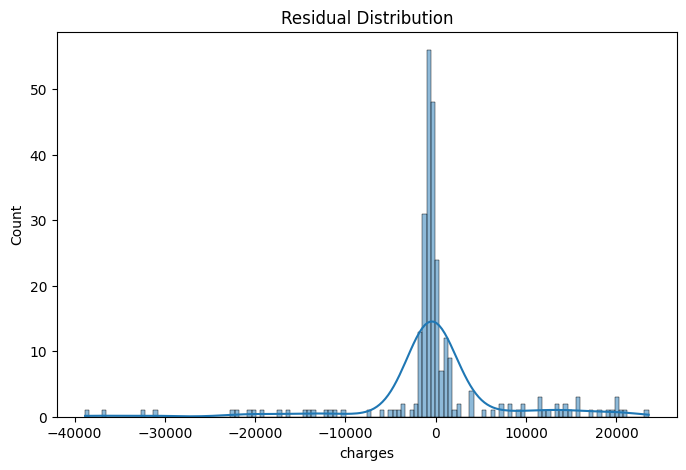

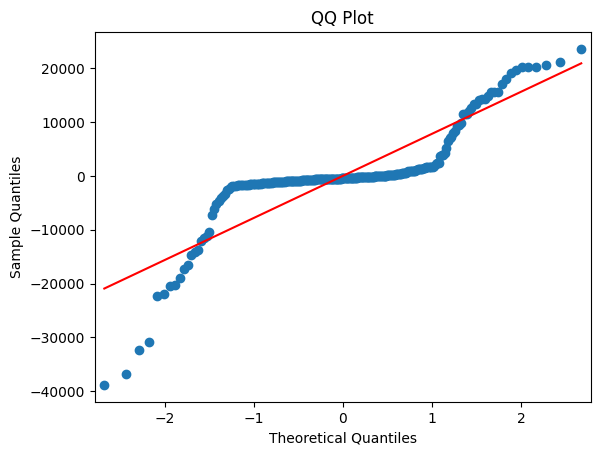


NORMALITY TEST (Shapiro)
Statistic: 0.7171524228059023
p-value: 5.018251364657209e-21

DURBIN WATSON (Independence)
Durbin-Watson: 1.9785080424810095

MULTICOLLINEARITY (VIF)
                           feature       VIF
0          onehotencoder__sex_male  1.674823
3  onehotencoder__region_southeast  1.361713
1        onehotencoder__smoker_yes  1.227961
2  onehotencoder__region_northwest  1.221704
4  onehotencoder__region_southwest  1.215576
6              standardscaler__bmi  1.091198
5              standardscaler__age  1.016265
7         standardscaler__children  1.003209

HETEROSCEDASTICITY (Breusch-Pagan)
LM Statistic: 96.94579635252173
p-value: 7.125143984678668e-23

MODEL COEFFICIENTS
                           feature  coefficient
1        onehotencoder__smoker_yes     1.551519
5              standardscaler__age     0.481643
7         standardscaler__children     0.112328
6              standardscaler__bmi     0.082146
2  onehotencoder__region_northwest    -0.056402
0          o

In [ ]:
model2 = linear_regression_diagnostics_updated(df_feat, target="charges")